In [3]:
library(data.table)
library(dplyr)

In [2]:
anno_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/annotate/'
# list.files(anno_dir)
eqtlgen_file = paste0(anno_dir,'2019-12-11-cis-eQTLsFDR0.05-ProbeLevel-CohortInfoRemoved-BonferroniAdded.txt.gz')
eqtlgen_df2 <- read.csv(gzfile(eqtlgen_file), sep="\t")
nrow(eqtlgen_df2)
head(eqtlgen_df2)

[1] 10507664

,Pvalue,SNP,SNPChr,SNPPos,AssessedAllele,OtherAllele,Zscore,Gene,GeneSymbol,GeneChr,GenePos,NrCohorts,NrSamples,FDR,BonferroniP
,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,3.2717e-310,rs12230244,12,10117369,T,A,200.7534,ENSG00000172322,CLEC12A,12,10126104,34,30596,0,4.1662e-302
2,3.2717e-310,rs12229020,12,10117683,G,C,200.6568,ENSG00000172322,CLEC12A,12,10126104,34,30596,0,4.1662e-302
3,3.2717e-310,rs61913527,12,10116198,T,C,200.2654,ENSG00000172322,CLEC12A,12,10126104,34,30598,0,4.1662e-302
4,3.2717e-310,rs2594103,12,10115428,T,C,200.0420,ENSG00000172322,CLEC12A,12,10126104,34,30598,0,4.1662e-302
5,3.2717e-310,rs12231833,12,10118428,A,G,199.9508,ENSG00000172322,CLEC12A,12,10126104,34,30592,0,4.1662e-302
6,3.2717e-310,rs12231872,12,10118747,C,G,199.7708,ENSG00000172322,CLEC12A,12,10126104,33,30268,0,4.1662e-302


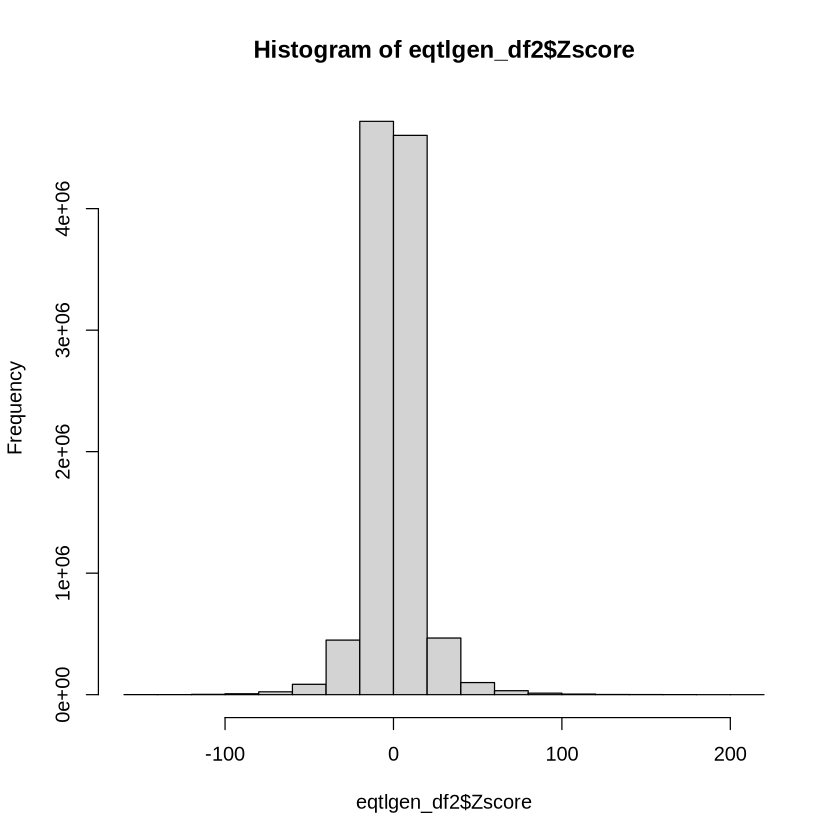

In [5]:
hist(eqtlgen_df2$Zscore)

In [6]:
eqtlgen_egenes = unique(eqtlgen_df2$Gene)
length(eqtlgen_egenes)

[1] 16987

In [7]:
suppl_tables_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/ms_tables/'
df_common_ct = as.data.frame(fread(paste0(suppl_tables_dir,'all_eqtls_fdr_5pct.tsv')))
nrow(df_common_ct)
head(df_common_ct)

[1] 154932

,gene,ACAT_p,top_MarkerID,top_pval,qvalue,celltype,ASDC_is_expressed,B_intermediate_is_expressed,B_memory_is_expressed,B_naive_is_expressed,⋯,ILC_is_egene,MAIT_is_egene,NK_is_egene,NK_CD56bright_is_egene,NK_Proliferating_is_egene,pDC_is_egene,Plasmablast_is_egene,Treg_is_egene,n_celltypes_expressed,n_celltypes_egene
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<int>
1,ENSG00000020633,5.782049e-04,1:24970252:A:C,1.42751e-05,1.925410e-02,ASDC,TRUE,TRUE,TRUE,TRUE,⋯,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,TRUE,TRUE,28,14
2,ENSG00000049247,1.234790e-12,1:7913587:T:TTTTTTGTTGTTGTTG,6.48378e-15,2.927374e-10,ASDC,TRUE,FALSE,FALSE,FALSE,⋯,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,TRUE,14,14
3,ENSG00000116288,8.678405e-04,1:8065826:C:CT,8.38885e-06,2.624051e-02,ASDC,TRUE,TRUE,TRUE,TRUE,⋯,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,28,26
4,ENSG00000117091,5.320189e-13,1:160705479:G:C,1.97810e-15,1.280392e-10,ASDC,TRUE,TRUE,TRUE,TRUE,⋯,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE,28,22
5,ENSG00000117394,1.212478e-05,1:42971584:CA:C,2.24877e-07,7.925513e-04,ASDC,TRUE,TRUE,TRUE,TRUE,⋯,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,27,10
6,ENSG00000117632,5.598092e-09,1:25972262:A:AT,4.89130e-11,7.800008e-07,ASDC,TRUE,TRUE,TRUE,TRUE,⋯,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE,FALSE,TRUE,28,15


In [8]:
tenk10k_egenes = unique(df_common_ct$gene)
length(tenk10k_egenes)

[1] 17674

In [9]:
tenk10k_egenes_unique = tenk10k_egenes[!(tenk10k_egenes %in% eqtlgen_egenes)]
length(tenk10k_egenes_unique)

[1] 4572

In [10]:
eqtlgen_egenes_unique = eqtlgen_egenes[!(eqtlgen_egenes %in% tenk10k_egenes)]
length(eqtlgen_egenes_unique)

[1] 3885

[1]   4.26260 200.75340  11.26008

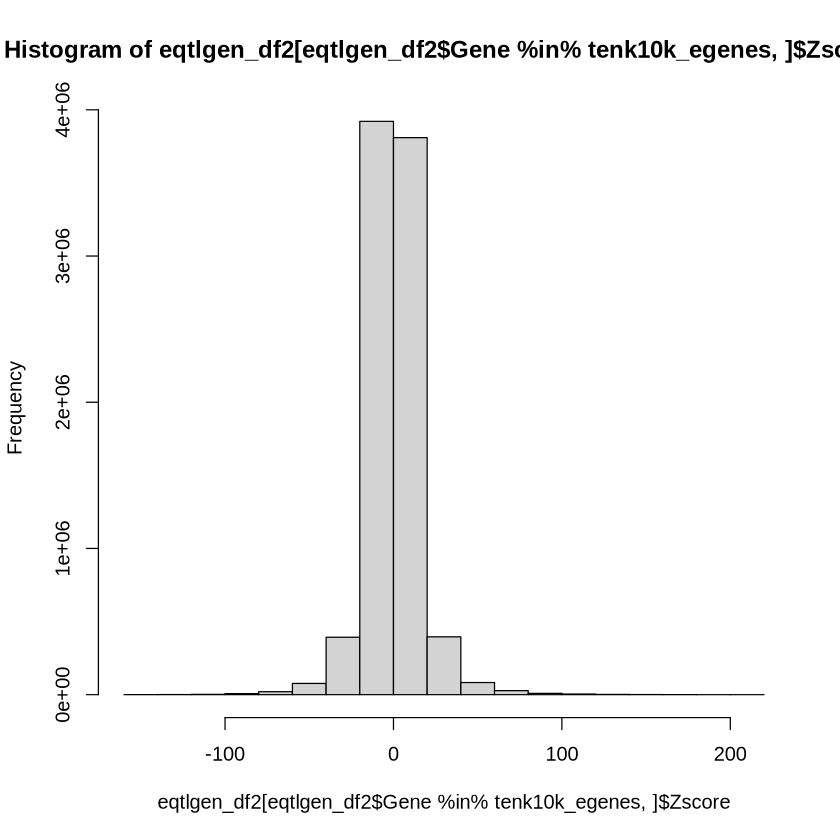

In [14]:
# shared
c(min(abs(eqtlgen_df2[eqtlgen_df2$Gene %in% tenk10k_egenes,]$Zscore)),
max(abs(eqtlgen_df2[eqtlgen_df2$Gene %in% tenk10k_egenes,]$Zscore)),
mean(abs(eqtlgen_df2[eqtlgen_df2$Gene %in% tenk10k_egenes,]$Zscore)))
hist(eqtlgen_df2[eqtlgen_df2$Gene %in% tenk10k_egenes,]$Zscore)

[1]   4.26260 193.71980  10.47037

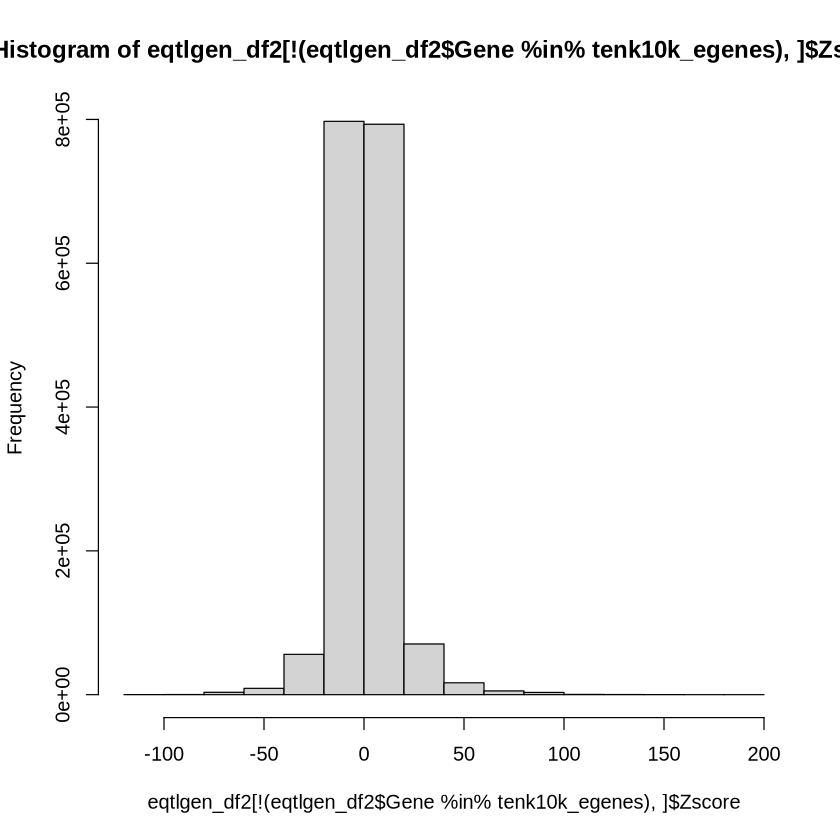

In [16]:
# not found by us
c(min(abs(eqtlgen_df2[!(eqtlgen_df2$Gene %in% tenk10k_egenes),]$Zscore)),
max(abs(eqtlgen_df2[!(eqtlgen_df2$Gene %in% tenk10k_egenes),]$Zscore)),
mean(abs(eqtlgen_df2[!(eqtlgen_df2$Gene %in% tenk10k_egenes),]$Zscore)))
hist(eqtlgen_df2[!(eqtlgen_df2$Gene %in% tenk10k_egenes),]$Zscore)

In [12]:
mean(df_common_ct[df_common_ct$gene %in% tenk10k_egenes_unique,'n_celltypes_expressed'])
mean(df_common_ct[df_common_ct$gene %in% tenk10k_egenes_unique,'n_celltypes_egene'])

[1] 22.91989

[1] 11.6763

In [14]:
mean(df_common_ct[!(df_common_ct$gene %in% tenk10k_egenes_unique),'n_celltypes_expressed'])
mean(df_common_ct[!(df_common_ct$gene %in% tenk10k_egenes_unique),'n_celltypes_egene'])

[1] 26.22944

[1] 13.92177

In [26]:
celltypes = unique(df_common_ct$celltype)
celltypes

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [51]:
rare_celltypes = c('ASDC','CD4_Proliferating','CD8_Proliferating','cDC1','cDC2','dnT','HSPC','ILC',
                   'NK_CD56bright','NK_Proliferating','pDC','Plasmablast')

In [52]:
df_egene_unique_genes = as.data.frame(df_common_ct)[,(colnames(df_common_ct) %in% c('gene',paste0(rare_celltypes,'_is_egene')))]
df_egene_unique_genes = df_egene_unique_genes[-which(duplicated(df_egene_unique_genes$gene)),]
rownames(df_egene_unique_genes) = df_egene_unique_genes$gene
df_egene_unique_genes$gene = c()
nrow(df_egene_unique_genes)
head(df_egene_unique_genes,2)

[1] 17674

,ASDC_is_egene,CD4_Proliferating_is_egene,CD8_Proliferating_is_egene,cDC1_is_egene,cDC2_is_egene,dnT_is_egene,HSPC_is_egene,ILC_is_egene,NK_CD56bright_is_egene,NK_Proliferating_is_egene,pDC_is_egene,Plasmablast_is_egene
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
ENSG00000020633,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
ENSG00000049247,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,FALSE,FALSE


In [53]:
df_egene_unique_genes$n_rare_celltypes_egene = rowSums(df_egene_unique_genes)
df_egene_unique_genes$gene = rownames(df_egene_unique_genes)
nrow(df_egene_unique_genes)
table(df_egene_unique_genes$n_rare_celltypes_egene)

[1] 17674


   0    1    2    3    4    5    6    7    8    9   10   11   12 
7590 4955 2218 1148  658  349  231  160  137   64   60   51   53 

In [55]:
table(df_egene_unique_genes[df_egene_unique_genes$gene %in% tenk10k_egenes_unique,'n_rare_celltypes_egene'])
table(df_egene_unique_genes[!(df_egene_unique_genes$gene %in% tenk10k_egenes_unique),'n_rare_celltypes_egene'])


   0    1    2    3    4    5    6    7    8    9   10   11   12 
2258 1448  418  174   89   60   25   34   21   16    8    8   13 


   0    1    2    3    4    5    6    7    8    9   10   11   12 
5332 3507 1800  974  569  289  206  126  116   48   52   43   40 

In [62]:
sum(table(df_egene_unique_genes[df_egene_unique_genes$gene %in% tenk10k_egenes_unique,'n_rare_celltypes_egene']))

[1] 4572

In [58]:
1448/2314

[1] 0.6257563

In [61]:
sum(table(df_egene_unique_genes[!(df_egene_unique_genes$gene %in% tenk10k_egenes_unique),'n_rare_celltypes_egene']))

[1] 13102

In [60]:
3507/7770

[1] 0.4513514

In [15]:
mydir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/ct_mean_expression_files/'
df_all = read.csv(paste0(mydir,'mean_expression_all_genes_all_celltypes.csv'), row.names = 1)

In [18]:
dim(df_all)
head(df_all,2)

[1] 37178    20

,gene,chrom,mean_ASDC,mean_B_intermediate,mean_B_memory,mean_B_naive,mean_CD14_Mono,mean_CD16_Mono,mean_CD4_CTL,mean_CD4_Naive,mean_CD4_Proliferating,mean_CD4_TCM,mean_CD4_TEM,mean_CD8_Naive,mean_CD8_Proliferating,mean_CD8_TCM,mean_CD8_TEM,mean_cDC1,mean_cDC2,mean_dnT
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,ENSG00000000419,20,1.0882353,0.43761037,0.4225268,0.35185948,0.5324157,0.5811292,0.35086813,0.3855598,1.2214689,0.4237658,0.3543120,0.4393066,0.8438874,0.4535226,0.38326088,0.9445317,0.9145955,0.5475507
3,ENSG00000000457,1,0.1941176,0.08857861,0.1054823,0.08342382,0.1218999,0.1714356,0.09576565,0.1009841,0.2751412,0.1181684,0.1020486,0.1042868,0.1591909,0.1224148,0.09342521,0.1449503,0.1571631,0.1579602


In [21]:
df_all$mean_overall = rowMeans(df_all[,3:20])

In [24]:
mean(df_all[df_all$gene %in% eqtlgen_egenes_unique,'mean_overall'])
mean(df_all[!(df_all$gene %in% eqtlgen_egenes_unique),'mean_overall'])

[1] 0.04370835

[1] 0.2936057

In [17]:
adata_var = as.data.frame(fread('/directflow/SCCGGroupShare/projects/anncuo/300libraries_n1925_adata_raw_var.csv'))
nrow(adata_var)
head(adata_var,2)

[1] 36842

,V1,gene_ids,feature_types,genome,mt,ribo,hb,chr,source,type,⋯,phase,attributes,gene_id,gene_name,gene_type,n_counts,highly_variable,means,dispersions,dispersions_norm
,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
1,ENSG00000290825,ENSG00000290825,Gene Expression,GRCh38,FALSE,FALSE,FALSE,chr1,HAVANA,gene,⋯,.,"gene_id """"ENSG00000290825.1""""; gene_type """"lncRNA""""; gene_name """"DDX11L2""""; level 2; tag """"overlaps_pseudogene"""";",ENSG00000290825.1,DDX11L2,lncRNA,213,FALSE,5.110075e-05,0.5333406,-0.26852970
2,ENSG00000243485,ENSG00000243485,Gene Expression,GRCh38,FALSE,FALSE,FALSE,chr1,HAVANA,gene,⋯,.,"gene_id """"ENSG00000243485.5""""; gene_type """"lncRNA""""; gene_name """"MIR1302-2HG""""; level 2; hgnc_id """"HGNC:52482""""; tag """"ncRNA_host""""; havana_gene """"OTTHUMG00000000959.2"""";",ENSG00000243485.5,MIR1302-2HG,lncRNA,109,FALSE,2.709609e-05,0.5989793,-0.05224023


In [24]:
df0 = adata_var %>% mutate(genelist = ifelse(gene_ids %in% eqtlgen_egenes_unique, "unique-to-eqtlgen","not-unique-to-eqtlgen"))
df01 = df0 %>% group_by(genelist) %>% summarise(mean_expr = mean(means))
df01

genelist,mean_expr
<chr>,<dbl>
not-unique-to-eqtlgen,0.13157535
unique-to-eqtlgen,0.01807888


In [25]:
df1 = adata_var %>% mutate(genelist = ifelse(gene_ids %in% tenk10k_egenes_unique, "unique-to-tenk10k","not-unique-to-tenk10k"))
df11 = df1 %>% group_by(genelist) %>% summarise(mean_expr = mean(means))
df11

genelist,mean_expr
<chr>,<dbl>
not-unique-to-tenk10k,0.12997883
unique-to-tenk10k,0.09237614
